<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Microsoft_stock_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/microsoft-stock-price-history")

print("Path to dataset files:", path)

100%|██████████| 374k/374k [00:00<00:00, 582kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adilshamim8/microsoft-stock-price-history/versions/17


In [2]:
import os

folder_path = "/root/.cache/kagglehub/datasets/adilshamim8/microsoft-stock-price-history/versions/17"

files = os.listdir(folder_path)

print(files)

['Microsoft_stock_data.csv']


In [3]:
import pandas as pd

file_path = os.path.join(folder_path, files[0])

df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
print(df.shape)

         Date     Close      High       Low      Open    Volume
0  1986-03-26  0.057666  0.058195  0.055550  0.056079  22752000
1  1986-03-27  0.058724  0.058724  0.057666  0.057666  16848000
2  1986-03-31  0.058195  0.058724  0.057137  0.058724  12873600
3  1986-04-01  0.057666  0.058195  0.057666  0.058195  11088000
4  1986-04-02  0.058195  0.059253  0.057666  0.057666  27014400
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
(10094, 6)


In [4]:
import pandas as pd
import numpy as np

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort chronologically
df = df.sort_values('Date').reset_index(drop=True)

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove any duplicate dates
df = df.drop_duplicates(subset='Date')

# Remove rows with missing or invalid closing prices
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])
df = df[df['Close'] > 0]

# Select the most recent 3 years of data
latest_date = df['Date'].max()
start_date = latest_date - pd.DateOffset(years=3)

msft = df[df['Date'] >= start_date].copy()

print("\nDate range:")
print(msft['Date'].min(), "to", msft['Date'].max())

print("\nNumber of observations:")
print(len(msft))

print("\nFirst 5 rows:")
print(msft.head())

print("\nLast 5 rows:")
print(msft.tail())

Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Date range:
2023-04-20 00:00:00 to 2026-04-20 00:00:00

Number of observations:
752

First 5 rows:
           Date       Close        High         Low        Open    Volume
9342 2023-04-20  279.491058  282.343520  278.484888  278.650968  23244400
9343 2023-04-21  279.149139  279.647321  276.511590  278.416490  21676400
9344 2023-04-24  275.251526  278.357982  272.272096  275.564130  26611000
9345 2023-04-25  269.048462  275.085487  268.999601  273.043841  45772200
9346 2023-04-26  288.536896  292.639745  285.957985  289.836144  64599200

Last 5 rows:
            Date       Close        High         Low        Open    Volume
10089 2026-04-14  393.109985  394.690002  386.519989  387.920013  37504500
10090 2026-04-15  411.220001  414.369995  396.730011  398.000000  45063400
10091 2026-04-16  420.260010  420.820007  412.140015  419.859985  41642400
10092 2026-04-17  422.790009  431.579987 

In [5]:
# Calculate daily logarithmic returns
msft['Log_Return'] = np.log(
    msft['Close'] / msft['Close'].shift(1)
)

# Remove first row because log return is undefined
msft = msft.dropna().reset_index(drop=True)

print(msft[['Date', 'Close', 'Log_Return']].head())

print("\nLog Return Summary:")
print(msft['Log_Return'].describe())

        Date       Close  Log_Return
0 2023-04-21  279.149139   -0.001224
1 2023-04-24  275.251526   -0.014061
2 2023-04-25  269.048462   -0.022794
3 2023-04-26  288.536896    0.069931
4 2023-04-27  297.778015    0.031525

Log Return Summary:
count    751.000000
mean       0.000536
std        0.014941
min       -0.105284
25%       -0.006891
50%        0.001154
75%        0.008731
max        0.096525
Name: Log_Return, dtype: float64


In [6]:
# Trading days per year
trading_days = 252

# Daily statistics
mean_daily_return = msft['Log_Return'].mean()
daily_volatility = msft['Log_Return'].std()

# Annualized parameters
annual_return = mean_daily_return * trading_days
annual_volatility = daily_volatility * np.sqrt(trading_days)

# Current / last observed stock price
S0 = msft['Close'].iloc[-1]

print(f"Latest Microsoft Price: ${S0:.2f}")
print(f"Mean Daily Log Return: {mean_daily_return:.6f}")
print(f"Daily Volatility: {daily_volatility:.6f}")
print(f"Annualized Log Return: {annual_return:.2%}")
print(f"Annualized Volatility: {annual_volatility:.2%}")

Latest Microsoft Price: $418.07
Mean Daily Log Return: 0.000536
Daily Volatility: 0.014941
Annualized Log Return: 13.51%
Annualized Volatility: 23.72%


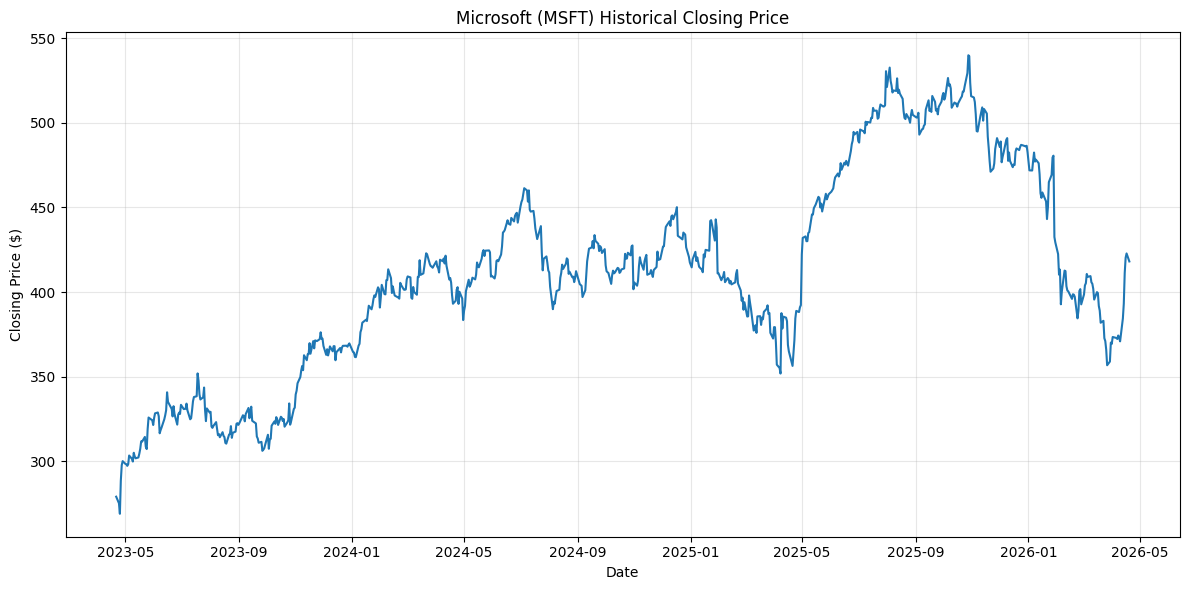

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(msft['Date'], msft['Close'])

plt.title('Microsoft (MSFT) Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

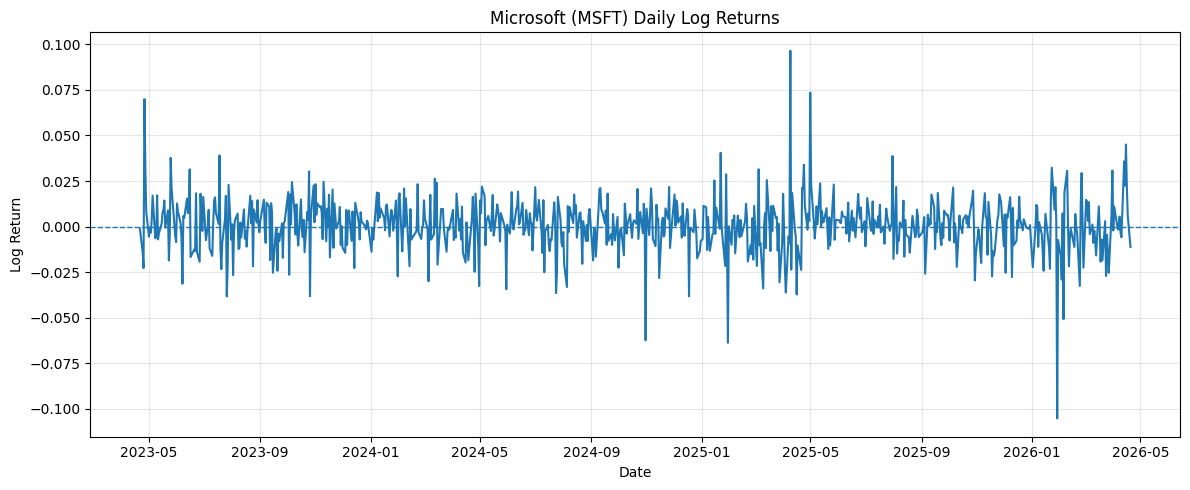

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(msft['Date'], msft['Log_Return'])

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.title('Microsoft (MSFT) Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Set random seed for reproducibility
np.random.seed(42)

# Simulation settings
simulation_days = 60
num_simulations = 1000
dt = 1 / 252

def simulate_gbm(S0, mu, sigma, days, simulations):
    paths = np.zeros((days + 1, simulations))
    paths[0] = S0

    for t in range(1, days + 1):

        z = np.random.normal(0, 1, simulations)

        paths[t] = paths[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * z
        )

    return paths


gbm_paths = simulate_gbm(
    S0=S0,
    mu=annual_return,
    sigma=annual_volatility,
    days=simulation_days,
    simulations=num_simulations
)

print("GBM simulation shape:", gbm_paths.shape)
print("Starting price:", gbm_paths[0, 0])
print("Mean simulated price after 60 days:", gbm_paths[-1].mean())

GBM simulation shape: (61, 1000)
Starting price: 418.0700073242188
Mean simulated price after 60 days: 431.7026998347889


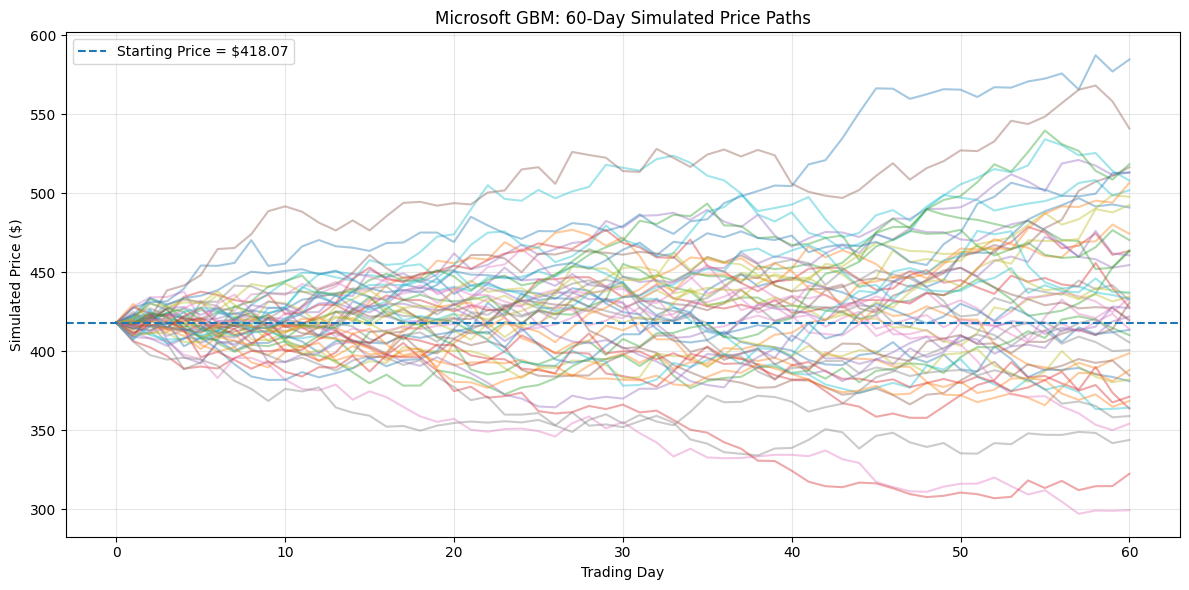

In [10]:
plt.figure(figsize=(12, 6))

for i in range(50):
    plt.plot(gbm_paths[:, i], alpha=0.4)

plt.axhline(
    y=S0,
    linestyle='--',
    label=f'Starting Price = ${S0:.2f}'
)

plt.title('Microsoft GBM: 60-Day Simulated Price Paths')
plt.xlabel('Trading Day')
plt.ylabel('Simulated Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

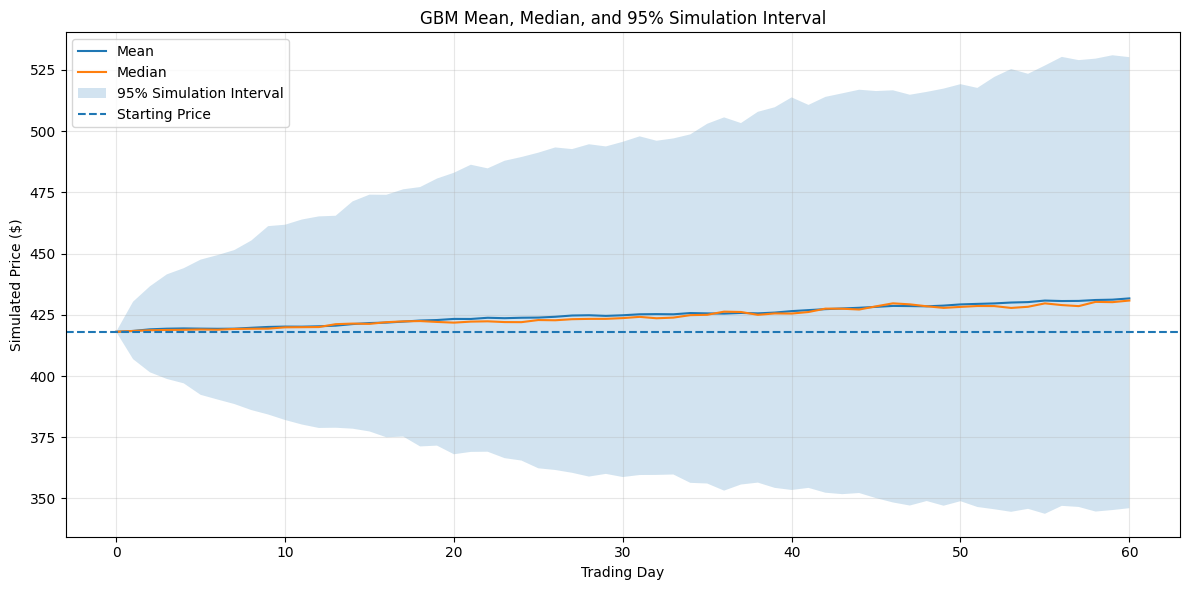

In [11]:
gbm_mean = np.mean(gbm_paths, axis=1)
gbm_median = np.median(gbm_paths, axis=1)

gbm_lower = np.percentile(gbm_paths, 2.5, axis=1)
gbm_upper = np.percentile(gbm_paths, 97.5, axis=1)

days = np.arange(simulation_days + 1)

plt.figure(figsize=(12, 6))

plt.plot(days, gbm_mean, label='Mean')
plt.plot(days, gbm_median, label='Median')

plt.fill_between(
    days,
    gbm_lower,
    gbm_upper,
    alpha=0.2,
    label='95% Simulation Interval'
)

plt.axhline(
    y=S0,
    linestyle='--',
    label='Starting Price'
)

plt.title('GBM Mean, Median, and 95% Simulation Interval')
plt.xlabel('Trading Day')
plt.ylabel('Simulated Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
gbm_final = gbm_paths[-1]

gbm_mean_final = np.mean(gbm_final)
gbm_median_final = np.median(gbm_final)

gbm_loss_probability = np.mean(gbm_final < S0)

gbm_lower_final = np.percentile(gbm_final, 2.5)
gbm_upper_final = np.percentile(gbm_final, 97.5)

print(f"Starting Price: ${S0:.2f}")
print(f"Mean 60-Day Price: ${gbm_mean_final:.2f}")
print(f"Median 60-Day Price: ${gbm_median_final:.2f}")
print(f"Probability of Loss: {gbm_loss_probability:.2%}")
print(
    f"95% Final Price Interval: "
    f"${gbm_lower_final:.2f} to ${gbm_upper_final:.2f}"
)

Starting Price: $418.07
Mean 60-Day Price: $431.70
Median 60-Day Price: $430.83
Probability of Loss: 40.20%
95% Final Price Interval: $346.03 to $530.22


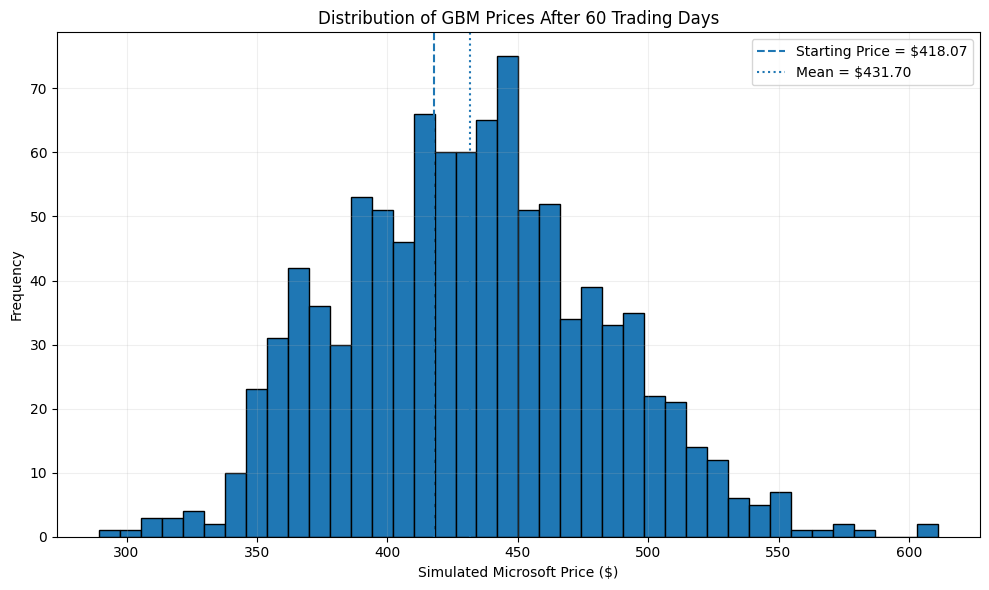

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    gbm_final,
    bins=40,
    edgecolor='black'
)

plt.axvline(
    S0,
    linestyle='--',
    label=f'Starting Price = ${S0:.2f}'
)

plt.axvline(
    gbm_mean_final,
    linestyle=':',
    label=f'Mean = ${gbm_mean_final:.2f}'
)

plt.title('Distribution of GBM Prices After 60 Trading Days')
plt.xlabel('Simulated Microsoft Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
# Estimate Ornstein-Uhlenbeck parameters from historical prices

ou_data = msft[['Close']].copy()

ou_data['Lag_Price'] = ou_data['Close'].shift(1)
ou_data['Price_Change'] = ou_data['Close'] - ou_data['Lag_Price']

ou_data = ou_data.dropna()

# Regression:
# Price_Change = a + b * Lag_Price

x = ou_data['Lag_Price'].values
y = ou_data['Price_Change'].values

b, a = np.polyfit(x, y, 1)

# Convert regression coefficients to OU parameters
theta_daily = -b
long_run_mean = a / theta_daily

# Residual volatility
predicted_change = a + b * x
residuals = y - predicted_change

sigma_daily_ou = np.std(residuals, ddof=1)

print(f"Estimated Daily Mean-Reversion Speed: {theta_daily:.6f}")
print(f"Estimated Long-Run Mean Price: ${long_run_mean:.2f}")
print(f"Estimated Daily OU Volatility: ${sigma_daily_ou:.4f}")


Estimated Daily Mean-Reversion Speed: 0.008259
Estimated Long-Run Mean Price: $432.92
Estimated Daily OU Volatility: $6.0189


In [15]:
# Reproducibility
np.random.seed(42)

def simulate_ou(
    S0,
    long_run_mean,
    theta_daily,
    sigma_daily,
    days=60,
    simulations=1000
):

    paths = np.zeros((days + 1, simulations))
    paths[0] = S0

    for t in range(1, days + 1):

        z = np.random.normal(0, 1, simulations)

        paths[t] = (
            paths[t - 1]
            + theta_daily *
              (long_run_mean - paths[t - 1])
            + sigma_daily * z
        )

    return paths


ou_paths = simulate_ou(
    S0=S0,
    long_run_mean=long_run_mean,
    theta_daily=theta_daily,
    sigma_daily=sigma_daily_ou,
    days=60,
    simulations=1000
)

print("OU simulation shape:", ou_paths.shape)
print("Starting Price:", ou_paths[0, 0])
print("Mean OU Price After 60 Days:", ou_paths[-1].mean())

OU simulation shape: (61, 1000)
Starting Price: 418.0700073242188
Mean OU Price After 60 Days: 423.89008387537905


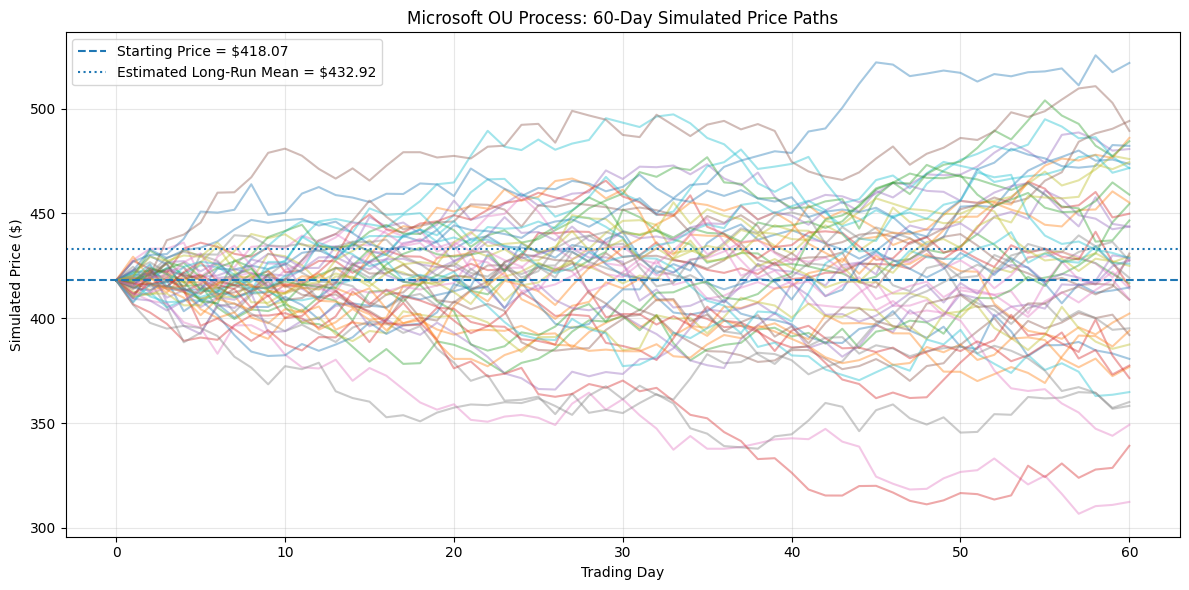

In [16]:
plt.figure(figsize=(12, 6))

for i in range(50):
    plt.plot(ou_paths[:, i], alpha=0.4)

plt.axhline(
    S0,
    linestyle='--',
    label=f'Starting Price = ${S0:.2f}'
)

plt.axhline(
    long_run_mean,
    linestyle=':',
    label=f'Estimated Long-Run Mean = ${long_run_mean:.2f}'
)

plt.title(
    'Microsoft OU Process: 60-Day Simulated Price Paths'
)

plt.xlabel('Trading Day')
plt.ylabel('Simulated Price ($)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

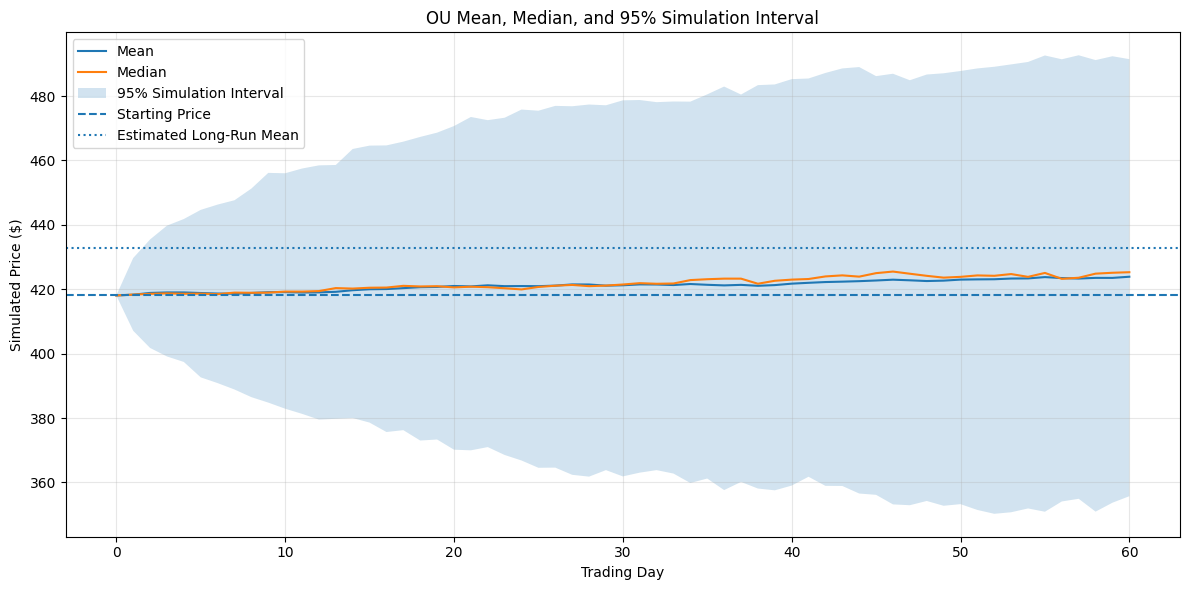

In [17]:
ou_mean = np.mean(ou_paths, axis=1)
ou_median = np.median(ou_paths, axis=1)

ou_lower = np.percentile(
    ou_paths,
    2.5,
    axis=1
)

ou_upper = np.percentile(
    ou_paths,
    97.5,
    axis=1
)

days = np.arange(61)

plt.figure(figsize=(12, 6))

plt.plot(
    days,
    ou_mean,
    label='Mean'
)

plt.plot(
    days,
    ou_median,
    label='Median'
)

plt.fill_between(
    days,
    ou_lower,
    ou_upper,
    alpha=0.2,
    label='95% Simulation Interval'
)

plt.axhline(
    S0,
    linestyle='--',
    label='Starting Price'
)

plt.axhline(
    long_run_mean,
    linestyle=':',
    label='Estimated Long-Run Mean'
)

plt.title(
    'OU Mean, Median, and 95% Simulation Interval'
)

plt.xlabel('Trading Day')
plt.ylabel('Simulated Price ($)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
ou_final = ou_paths[-1]

ou_mean_final = np.mean(ou_final)
ou_median_final = np.median(ou_final)

ou_loss_probability = np.mean(
    ou_final < S0
)

ou_lower_final = np.percentile(
    ou_final,
    2.5
)

ou_upper_final = np.percentile(
    ou_final,
    97.5
)

print(f"Starting Price: ${S0:.2f}")
print(f"Mean 60-Day OU Price: ${ou_mean_final:.2f}")
print(f"Median 60-Day OU Price: ${ou_median_final:.2f}")
print(f"Probability of Loss: {ou_loss_probability:.2%}")

print(
    f"95% Final Price Interval: "
    f"${ou_lower_final:.2f} to "
    f"${ou_upper_final:.2f}"
)

Starting Price: $418.07
Mean 60-Day OU Price: $423.89
Median 60-Day OU Price: $425.29
Probability of Loss: 43.20%
95% Final Price Interval: $355.70 to $491.48


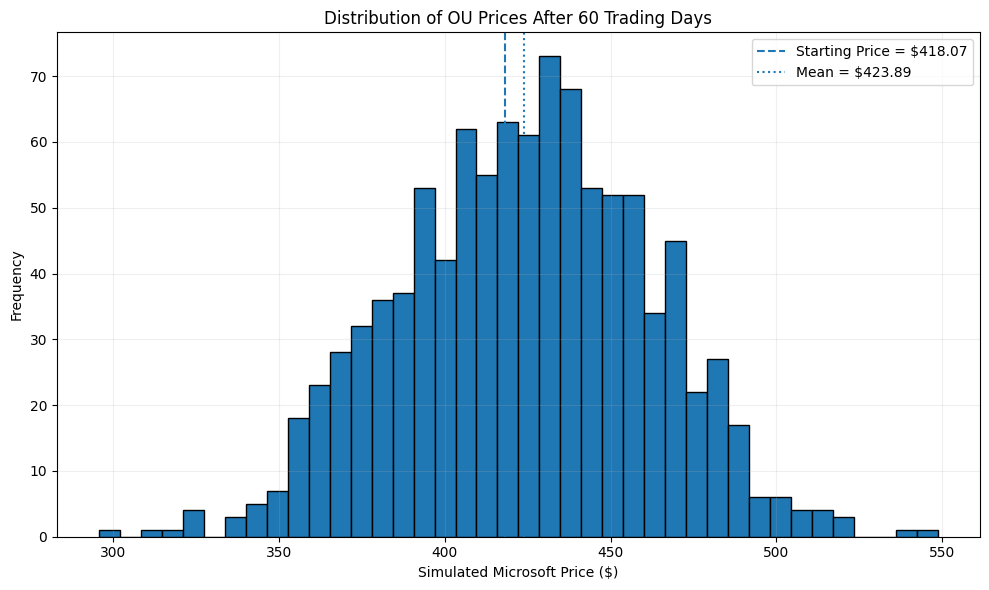

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    ou_final,
    bins=40,
    edgecolor='black'
)

plt.axvline(
    S0,
    linestyle='--',
    label=f'Starting Price = ${S0:.2f}'
)

plt.axvline(
    ou_mean_final,
    linestyle=':',
    label=f'Mean = ${ou_mean_final:.2f}'
)

plt.title(
    'Distribution of OU Prices After 60 Trading Days'
)

plt.xlabel('Simulated Microsoft Price ($)')
plt.ylabel('Frequency')

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [22]:
comparison = pd.DataFrame({
    'Metric': [
        'Starting Price',
        'Mean 60-Day Price',
        'Median 60-Day Price',
        'Probability of Loss',
        '2.5th Percentile',
        '97.5th Percentile'
    ],

    'GBM': [
        S0,
        gbm_mean_final,
        gbm_median_final,
        gbm_loss_probability,
        gbm_lower_final,
        gbm_upper_final
    ],

    'Ornstein-Uhlenbeck': [
        S0,
        ou_mean_final,
        ou_median_final,
        ou_loss_probability,
        ou_lower_final,
        ou_upper_final
    ]
})

comparison

,Metric,GBM,Ornstein-Uhlenbeck
0,Starting Price,418.070007,418.070007
1,Mean 60-Day Price,431.702700,423.890084
2,Median 60-Day Price,430.828027,425.293863
3,Probability of Loss,0.402000,0.432000
4,2.5th Percentile,346.034930,355.703656
5,97.5th Percentile,530.222003,491.477374
